# Stage 4 — Phase 2.4/2.5/2.6: Model Setup, Prompting, Parsing, Budget Gate

Builds the eval pipeline for one candidate at a time. Starting with **Qwen3-VL-8B-Instruct**
to prove the pipeline end-to-end, then the same structure repeats for InternVL3-8B and
Molmo-7B-D-0924.

**Candidates (locked per decision 2026-07-09):**
- Qwen3-VL: `Qwen/Qwen3-VL-8B-Instruct`
- InternVL3: `OpenGVLab/InternVL3-8B-hf`
- Molmo: `allenai/Molmo-7B-D-0924`

## 0. Configuration + mount

In [2]:
DRIVE_ROOT   = "/content/drive/MyDrive/pid_project/data"
KAGGLE_DIR   = "kaggle_pid_symbols"
GUPTA_DIR    = "gupta_pid"

from google.colab import drive
drive.mount('/content/drive')

import os, json, time, re, random
from pathlib import Path
from PIL import Image, ImageDraw
import torch
from transformers import (
    AutoProcessor, AutoModelForImageTextToText, AutoModelForCausalLM,
    GenerationConfig, StoppingCriteriaList, MaxTimeCriteria,
)

ROOT = Path(DRIVE_ROOT)
kaggle_p = ROOT / KAGGLE_DIR
gupta_p = ROOT / GUPTA_DIR
print("Kaggle:", kaggle_p.exists(), "| Gupta:", gupta_p.exists())

Mounted at /content/drive
Kaggle: True | Gupta: True


## Common scoring schema (2.4 — the fixed target format)

Every model's raw output gets parsed into this schema, regardless of what format the model
natively emits (bbox-JSON, points, its own dialect). This is deliberately simpler than the
real agent's `DetectionRecord` (`Agent_Pipeline_Facts.md` §2) — we don't need `provenance`
nesting, tag parsing, etc. for benchmarking, just enough to score detection + typing:

```python
{
    "bbox": [x0, y0, x1, y1],   # tile-local pixel coords, xyxy, absolute (not normalized)
    "confidence": float,         # 0.0-1.0
    "entity_type": str | None,   # typing eval (Kaggle) only; None/ignored for Gupta detection eval
}
```

Ground truth (ours, already built) uses the same `bbox` convention — see `parse_yolo_line`/
`yolo_line_to_xyxy` in the Phase 0-1 and Phase 2 notebooks.

## Load Qwen3-VL-8B-Instruct

In [ ]:
QWEN_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

t0 = time.time()
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
qwen_model = AutoModelForImageTextToText.from_pretrained(
    QWEN_MODEL_ID, dtype=torch.bfloat16, device_map="cuda"
)
print(f"Loaded {QWEN_MODEL_ID} in {time.time()-t0:.1f}s")
print("VRAM used:", f"{torch.cuda.memory_allocated()/1e9:.1f} GB")

## Prompt engineering (2.5) — Qwen3-VL

Ask for strict JSON matching the common schema directly, to minimize parsing work. Qwen3-VL
is documented to be comfortable with bbox-JSON output.

In [3]:
SYMBOL_DETECTION_PROMPT = """You are analyzing a tile cropped from a Piping & Instrumentation \
Diagram (P&ID). Detect every symbol (valve, instrument, flange, nozzle, safety device, or \
other P&ID symbol) visible in this image.

Respond with ONLY a JSON array of arrays, no other text, no explanation. Each inner array is
exactly: [x0, y0, x1, y1, confidence, "entity_type"]

Example: [[100, 200, 150, 260, 0.95, "valve"], [400, 50, 430, 90, 0.88, "instrument"]]

Coordinates are absolute pixel coordinates in this image (top-left origin, x right, y down),
NOT normalized. confidence is a float 0.0-1.0. If you see no symbols, respond with an empty
array: []"""

from transformers import StoppingCriteriaList, MaxTimeCriteria

def run_qwen(image: Image.Image, prompt: str = SYMBOL_DETECTION_PROMPT, max_time_s: float = 60.0):
    """max_time_s is a hard wall-clock cap — protects against degenerate generation loops that
    would otherwise burn the full max_new_tokens budget (observed: a stuck loop can take 170s+
    on a dense tile). Distinct from max_new_tokens, which only caps token COUNT, not time."""
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}],
    }]
    inputs = qwen_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(qwen_model.device)
    t0 = time.time()
    with torch.no_grad():
        out = qwen_model.generate(
            **inputs, max_new_tokens=3072, do_sample=False,
            stopping_criteria=StoppingCriteriaList([MaxTimeCriteria(max_time=max_time_s)]),
        )
    latency = time.time() - t0
    gen_tokens = out[:, inputs["input_ids"].shape[1]:]
    text = qwen_processor.batch_decode(gen_tokens, skip_special_tokens=True)[0]
    return text, latency

## Parser (2.5) — round-trip Qwen's raw output into the common schema

In [4]:
import re

def parse_qwen_output(text):
    """Returns (detections, error). detections is a list of common-schema dicts, or None if
    parsing failed. error is None on success, else a short description."""
    cleaned = text.strip()
    # strip markdown code fences if the model wraps its JSON despite instructions
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned)
    cleaned = re.sub(r'\s*```$', '', cleaned)
    # repair a real observed glitch: model emits "0:97" instead of "0.97" (colon for decimal point)
    cleaned = re.sub(r'(?<=: )(\d):(\d+)(?=[,}\s])', r'\1.\2', cleaned)
    try:
        data = json.loads(cleaned)
    except json.JSONDecodeError as e:
        return None, f"JSONDecodeError: {e}"
    if not isinstance(data, list):
        return None, f"expected a JSON array, got {type(data).__name__}"
    detections = []
    for i, item in enumerate(data):
        if not (isinstance(item, list) and len(item) == 6):
            return None, f"item {i} malformed, expected [x0,y0,x1,y1,confidence,entity_type]: {item}"
        x0, y0, x1, y1, confidence, entity_type = item
        detections.append({
            "bbox": [float(x0), float(y0), float(x1), float(y1)],
            "confidence": float(confidence),
            "entity_type": str(entity_type),
        })
    return detections, None

## Round-trip test on one sample tile (2.4 confirm)

In [ ]:
# pick a tile that actually has ground-truth boxes, so round-trip tests are informative
def find_labeled_sample(min_boxes=3, max_boxes=8):
    for lbl in (kaggle_p / "labels").glob("*.txt"):
        n = len([l for l in lbl.read_text().splitlines() if l.strip()])
        if min_boxes <= n <= max_boxes:
            return kaggle_p / "images" / f"{lbl.stem}.jpg", lbl, n
    return None, None, 0

sample_img_path, sample_label_path, gt_count = find_labeled_sample()
sample_img = Image.open(sample_img_path).convert("RGB")
print("Sample image:", sample_img_path.name, sample_img.size, f"| ground truth boxes: {gt_count}")


In [ ]:
raw_text, latency = run_qwen(sample_img)
print(f"Latency: {latency:.2f}s")
print(f"\nRaw output:\n{raw_text[:1000]}")

detections, error = parse_qwen_output(raw_text)
if error:
    print(f"\n❌ PARSE FAILED: {error}")
else:
    print(f"\n✓ Parsed {len(detections)} detections into common schema")
    for d in detections[:5]:
        print(" ", d)

Green = ground truth, Red = Qwen prediction


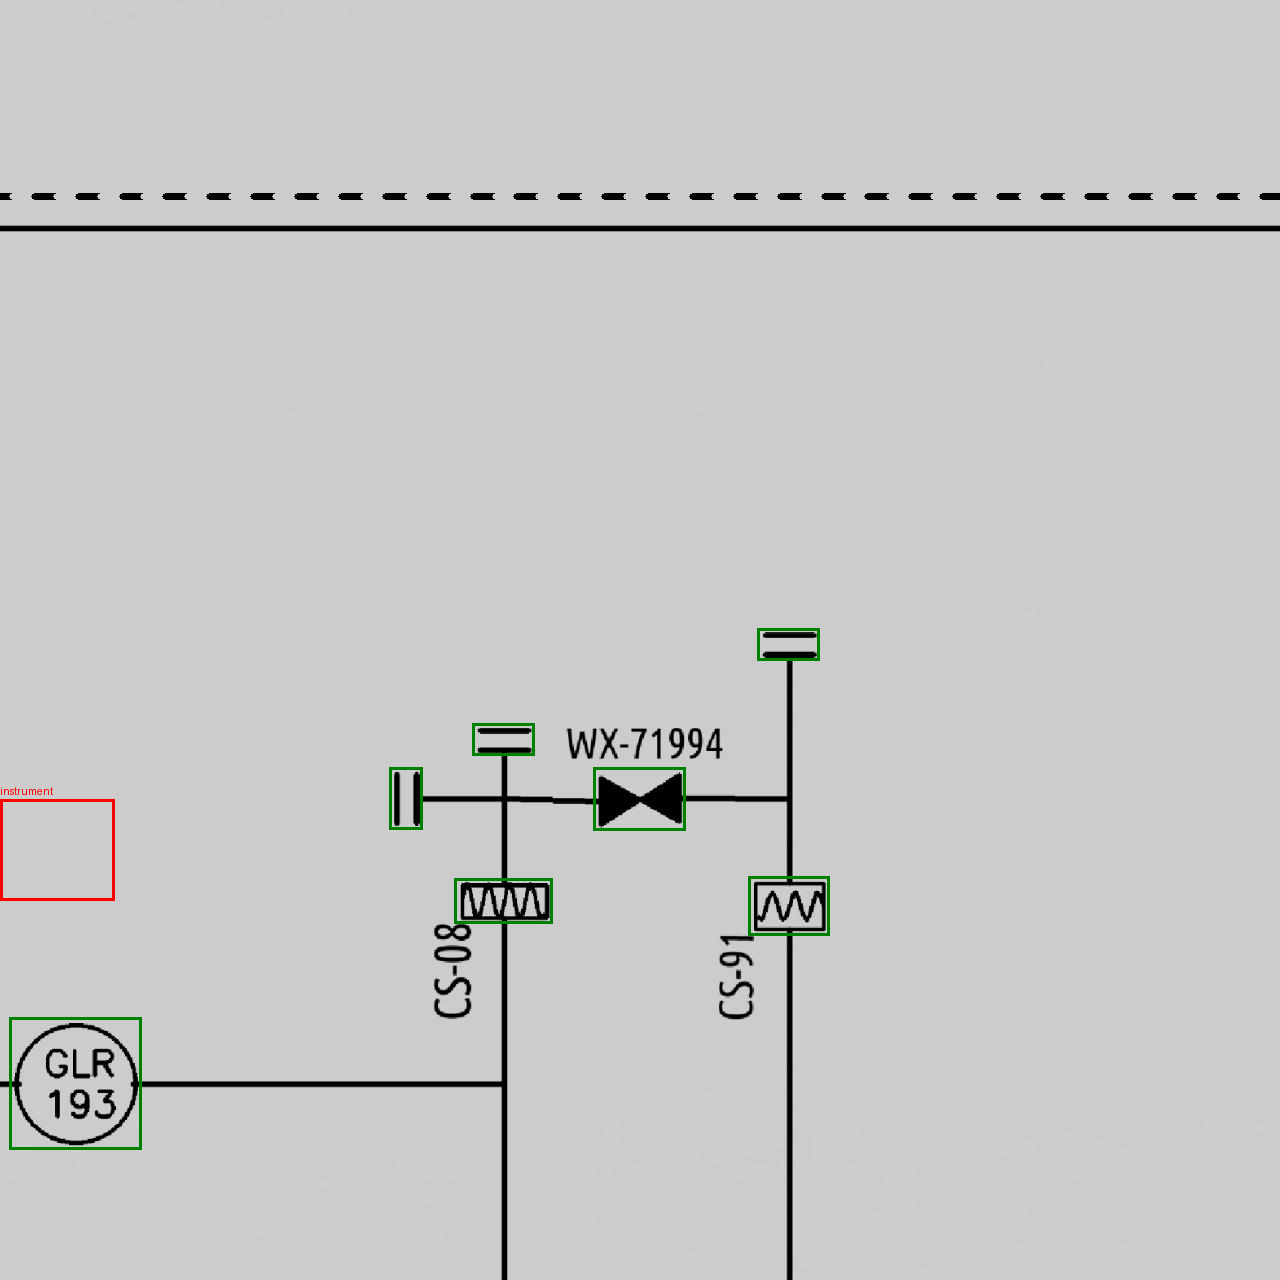

In [9]:
from PIL import ImageDraw

vis = sample_img.copy()
draw = ImageDraw.Draw(vis)

# ground truth in green
for line in sample_label_path.read_text().splitlines():
    if line.strip():
        parts = line.split()
        cx, cy, w, h = (float(v) for v in parts[1:5])
        cx, cy, w, h = cx * 1280, cy * 1280, w * 1280, h * 1280
        draw.rectangle([cx - w/2, cy - h/2, cx + w/2, cy + h/2], outline="green", width=3)

# Qwen's prediction in red
for d in detections:
    draw.rectangle(d["bbox"], outline="red", width=3)
    draw.text((d["bbox"][0], max(0, d["bbox"][1] - 14)), d["entity_type"], fill="red")

print("Green = ground truth, Red = Qwen prediction")
display(vis)

## 2.5 confirm — parse-failure rate over a 10-sample dev set

Checklist bar: each model's parser round-trips ≥95% of a 10-sample dev set without manual
fixup. This measures **parse success**, not detection accuracy — a model can parse
perfectly while still being wrong about what it sees (as the single-sample check just
showed). Both numbers matter, tracked separately.

In [6]:
import random
random.seed(0)

dev_set = []
for lbl in (kaggle_p / "labels").glob("*.txt"):
    n = len([l for l in lbl.read_text().splitlines() if l.strip()])
    if n >= 1:
        dev_set.append((kaggle_p / "images" / f"{lbl.stem}.jpg", lbl, n))
    if len(dev_set) >= 200:  # sample pool, then subsample below
        break
dev_set = random.sample(dev_set, 10)

results = []
for img_path, lbl_path, gt_n in dev_set:
    img = Image.open(img_path).convert("RGB")
    raw_text, latency = run_qwen(img)
    detections, error = parse_qwen_output(raw_text)
    results.append({
        "image": img_path.name, "gt_boxes": gt_n,
        "parsed_ok": error is None,
        "n_detections": len(detections) if detections else 0,
        "error": error, "latency": latency,
    })
    status = "OK" if error is None else f"FAIL: {error}"
    print(f"{img_path.name:20s} gt={gt_n:2d} pred={len(detections) if detections else 0:2d} "
          f"latency={latency:.2f}s  [{status}]")

n_ok = sum(r["parsed_ok"] for r in results)
parse_rate = n_ok / len(results)
print(f"\nParse success: {n_ok}/{len(results)} ({parse_rate*100:.0f}%)")
print("✓ meets ≥95% bar" if parse_rate >= 0.95 else "✗ BELOW 95% bar — needs prompt work")

avg_latency = sum(r["latency"] for r in results) / len(results)
print(f"Avg latency: {avg_latency:.2f}s/tile")

101_0_3840.jpg       gt= 5 pred= 6 latency=10.58s  [OK]
103_0_1920.jpg       gt= 4 pred= 0 latency=0.52s  [OK]
101_1280_4480.jpg    gt= 9 pred= 0 latency=60.04s  [FAIL: JSONDecodeError: Expecting value: line 1 column 1301 (char 1300)]
0_1280_3840.jpg      gt=10 pred= 0 latency=60.05s  [FAIL: JSONDecodeError: Expecting ',' delimiter: line 1 column 1492 (char 1491)]
100_1920_2560.jpg    gt=14 pred= 0 latency=60.01s  [FAIL: JSONDecodeError: Expecting ',' delimiter: line 1 column 1425 (char 1424)]
101_3200_1920.jpg    gt=10 pred= 0 latency=60.06s  [FAIL: JSONDecodeError: Expecting value: line 1 column 1402 (char 1401)]
101_2560_3840.jpg    gt= 2 pred= 4 latency=6.73s  [OK]
101_1280_1920.jpg    gt=16 pred= 0 latency=60.05s  [FAIL: JSONDecodeError: Expecting ',' delimiter: line 1 column 1496 (char 1495)]
100_2560_4480.jpg    gt= 2 pred= 0 latency=0.53s  [OK]
101_2560_2560.jpg    gt=10 pred= 0 latency=60.02s  [FAIL: JSONDecodeError: Expecting value: line 1 column 1487 (char 1486)]

Parse succ

In [ ]:
img_path = kaggle_p / "images" / "101_1280_4480.jpg"
img = Image.open(img_path).convert("RGB")
raw_text, latency = run_qwen(img)
print(f"Output length: {len(raw_text)} chars | latency: {latency:.1f}s")

In [12]:
img_path = kaggle_p / "images" / "101_3200_1920.jpg"
img = Image.open(img_path).convert("RGB")
raw_text, latency = run_qwen(img)
print(repr(raw_text))

'[{"bbox": [0, 184, 97, 272], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [100, 108, 175, 192], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [384, 198, 482, 272], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [892, 78, 977, 168], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [384, 580, 500, 642], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [517, 294, 568, 356], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [257, 204, 300, 284], "confidence": 0.97, "entity_type": "flange"}, {"bbox": [0, 588, 35, 698], "confidence": 0.97, "entity_type": "flange"}, {"bbox": [647, 204, 677, 250], "confidence": 0:97, "entity_type": "flange"}, {"bbox": [517, 642, 568, 677], "confidence": 0.97, "entity_type": "flange"}, {"bbox": [777, 592, 807, 642], "confidence": 0.97, "entity_type": "nozzle"}, {"bbox": [100, 108, 175, 192], "confidence": 0.97, "entity_type": "safety device"}]'


In [13]:
img_path = kaggle_p / "images" / "101_1280_4480.jpg"
img = Image.open(img_path).convert("RGB")
raw_text, latency = run_qwen(img)
print(f"Output length: {len(raw_text)} chars")
print(repr(raw_text[-300:]))

Output length: 4148 chars
'"bbox": [162, 1860, 252, 1917], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [162, 1847, 252, 1904], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [162, 1917, 252, 1974], "confidence": 0.97, "entity_type": "instrument"}, {"bbox": [162, 1904, 252, 1961], "confidence": 0.97,'


## Load InternVL3-8B

Same `AutoModelForImageTextToText`/`AutoProcessor` pattern as Qwen3-VL (both are HF-ported
checkpoints). No native bbox/detection output format documented — it's a general VQA
model — so we start with the same prompt/parser that worked for Qwen and adjust based on
actual behavior. VRAM: Qwen3-VL (17.5GB) stays loaded; A100-80GB has plenty of room for both.

In [8]:
INTERNVL_MODEL_ID = "OpenGVLab/InternVL3-8B-hf"

t0 = time.time()
internvl_processor = AutoProcessor.from_pretrained(INTERNVL_MODEL_ID)
internvl_model = AutoModelForImageTextToText.from_pretrained(
    INTERNVL_MODEL_ID, dtype=torch.bfloat16, device_map="cuda"
)
print(f"Loaded {INTERNVL_MODEL_ID} in {time.time()-t0:.1f}s")
print("VRAM used:", f"{torch.cuda.memory_allocated()/1e9:.1f} GB")

processor_config.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/481 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.96k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/6.86k [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/781 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Loaded OpenGVLab/InternVL3-8B-hf in 55.9s
VRAM used: 33.4 GB


## Prompt + generation — InternVL3

Reuses `SYMBOL_DETECTION_PROMPT` and the same array-of-arrays format that worked for Qwen.
Same wall-clock timeout guard (60s) — same degenerate-loop risk applies to any model asked
to enumerate many structured detections.

In [9]:
def run_internvl(image: Image.Image, prompt: str = SYMBOL_DETECTION_PROMPT, max_time_s: float = 60.0):
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}],
    }]
    inputs = internvl_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(internvl_model.device)
    t0 = time.time()
    with torch.no_grad():
        out = internvl_model.generate(
            **inputs, max_new_tokens=3072, do_sample=False,
            stopping_criteria=StoppingCriteriaList([MaxTimeCriteria(max_time=max_time_s)]),
        )
    latency = time.time() - t0
    gen_tokens = out[:, inputs["input_ids"].shape[1]:]
    text = internvl_processor.batch_decode(gen_tokens, skip_special_tokens=True)[0]
    return text, latency

## Round-trip test — InternVL3 on the same labeled sample tile

In [10]:
raw_text, latency = run_internvl(sample_img)
print(f"Sample image: {sample_img_path.name} | ground truth boxes: {gt_count}")
print(f"Latency: {latency:.2f}s")
print(f"\nRaw output:\n{raw_text[:1000]}")

detections, error = parse_qwen_output(raw_text)  # same parser, same target format
if error:
    print(f"\n❌ PARSE FAILED: {error}")
else:
    print(f"\n✓ Parsed {len(detections)} detections into common schema")
    for d in detections[:8]:
        print(" ", d)

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Sample image: 0_0_1280.jpg | ground truth boxes: 7
Latency: 5.48s

Raw output:
[[370, 610, 400, 650, 0.95, "valve"], [440, 560, 550, 640, 0.95, "instrument"], [560, 680, 590, 720, 0.95, "flange"], [370, 770, 400, 810, 0.95, "flange"], [18, 800, 120, 890, 0.95, "instrument"]]

✓ Parsed 5 detections into common schema
  {'bbox': [370.0, 610.0, 400.0, 650.0], 'confidence': 0.95, 'entity_type': 'valve'}
  {'bbox': [440.0, 560.0, 550.0, 640.0], 'confidence': 0.95, 'entity_type': 'instrument'}
  {'bbox': [560.0, 680.0, 590.0, 720.0], 'confidence': 0.95, 'entity_type': 'flange'}
  {'bbox': [370.0, 770.0, 400.0, 810.0], 'confidence': 0.95, 'entity_type': 'flange'}
  {'bbox': [18.0, 800.0, 120.0, 890.0], 'confidence': 0.95, 'entity_type': 'instrument'}


## 2.5 confirm — InternVL3 parse-failure rate over the same 10-sample dev set

In [11]:
results_internvl = []
confidences_seen = []
for img_path, lbl_path, gt_n in dev_set:
    img = Image.open(img_path).convert("RGB")
    raw_text, latency = run_internvl(img)
    detections, error = parse_qwen_output(raw_text)
    results_internvl.append({
        "image": img_path.name, "gt_boxes": gt_n,
        "parsed_ok": error is None,
        "n_detections": len(detections) if detections else 0,
        "error": error, "latency": latency,
    })
    if detections:
        confidences_seen += [d["confidence"] for d in detections]
    status = "OK" if error is None else f"FAIL: {error}"
    print(f"{img_path.name:20s} gt={gt_n:2d} pred={len(detections) if detections else 0:2d} "
          f"latency={latency:.2f}s  [{status}]")

n_ok = sum(r["parsed_ok"] for r in results_internvl)
parse_rate = n_ok / len(results_internvl)
print(f"\nParse success: {n_ok}/{len(results_internvl)} ({parse_rate*100:.0f}%)")
print("✓ meets ≥95% bar" if parse_rate >= 0.95 else "✗ BELOW 95% bar")

avg_latency = sum(r["latency"] for r in results_internvl) / len(results_internvl)
print(f"Avg latency: {avg_latency:.2f}s/tile")

print(f"\nConfidence distribution: min={min(confidences_seen):.2f} "
      f"max={max(confidences_seen):.2f} unique_values={sorted(set(confidences_seen))}")

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


101_0_3840.jpg       gt= 5 pred= 3 latency=3.19s  [OK]


[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


103_0_1920.jpg       gt= 4 pred= 3 latency=3.14s  [OK]


[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


...

101_2560_3840.jpg    gt= 2 pred= 0 latency=60.01s  [FAIL: JSONDecodeError: Expecting ',' delimiter: line 1 column 2141 (char 2140)]


[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


101_1280_1920.jpg    gt=16 pred= 5 latency=5.76s  [OK]


[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


100_2560_4480.jpg    gt= 2 pred= 1 latency=1.19s  [OK]
101_2560_2560.jpg    gt=10 pred=11 latency=11.37s  [OK]

Parse success: 6/10 (60%)
✗ BELOW 95% bar
Avg latency: 27.39s/tile

Confidence distribution: min=0.75 max=0.98 unique_values=[0.75, 0.8, 0.85, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98]


In [2]:
# pick a tile that actually has ground-truth boxes, so round-trip tests are informative
def find_labeled_sample(min_boxes=3, max_boxes=8):
    for lbl in (kaggle_p / "labels").glob("*.txt"):
        n = len([l for l in lbl.read_text().splitlines() if l.strip()])
        if min_boxes <= n <= max_boxes:
            return kaggle_p / "images" / f"{lbl.stem}.jpg", lbl, n
    return None, None, 0

sample_img_path, sample_label_path, gt_count = find_labeled_sample()
sample_img = Image.open(sample_img_path).convert("RGB")
print("Sample image:", sample_img_path.name, sample_img.size, f"| ground truth boxes: {gt_count}")

Sample image: 85_1920_1280.jpg (1280, 1280) | ground truth boxes: 8


---
## Molmo2 prerequisites — run these first in a fresh runtime

Everything below is needed before the Molmo2 section works standalone (fresh kernel,
not shared state from Qwen3-VL/InternVL3 cells earlier in this notebook).

**Prereq 1 — Config, Drive mount, shared imports**

In [3]:
DRIVE_ROOT   = "/content/drive/MyDrive/pid_project/data"
KAGGLE_DIR   = "kaggle_pid_symbols"
GUPTA_DIR    = "gupta_pid"

from google.colab import drive
drive.mount('/content/drive')

import os, json, time, re, random
from pathlib import Path
from PIL import Image, ImageDraw
import torch
from transformers import (
    AutoProcessor, AutoModelForImageTextToText, AutoModelForCausalLM,
    GenerationConfig, StoppingCriteriaList, MaxTimeCriteria,
)

ROOT = Path(DRIVE_ROOT)
kaggle_p = ROOT / KAGGLE_DIR
gupta_p = ROOT / GUPTA_DIR
print("Kaggle:", kaggle_p.exists(), "| Gupta:", gupta_p.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kaggle: True | Gupta: True


**Prereq 2 — Pick a labeled sample tile**

In [23]:
# pick a tile that actually has ground-truth boxes, so round-trip tests are informative
def find_labeled_sample(min_boxes=3, max_boxes=8):
    for lbl in (kaggle_p / "labels").glob("*.txt"):
        n = len([l for l in lbl.read_text().splitlines() if l.strip()])
        if min_boxes <= n <= max_boxes:
            return kaggle_p / "images" / f"{lbl.stem}.jpg", lbl, n
    return None, None, 0

sample_img_path, sample_label_path, gt_count = find_labeled_sample()
sample_img = Image.open(sample_img_path).convert("RGB")
print("Sample image:", sample_img_path.name, sample_img.size, f"| ground truth boxes: {gt_count}")

Sample image: 85_1920_1280.jpg (1280, 1280) | ground truth boxes: 8


**Prereq 3 — Pin transformers==4.57.1, then restart runtime before continuing**

### ⚠️ Version pin note — read before running Molmo2

Molmo2-O-7B's model card pins `transformers==4.57.1` exactly (confirmed from its own
Quick Start instructions). Our session otherwise runs on a newer version (5.12.1) that
Qwen3-VL and InternVL3 both load fine on. Rather than switch versions back and forth
every session (an ongoing cost), we're pinning **only for this Molmo2 section** for now
and accepting per-candidate versions as a known tradeoff.

**Deferred experiment, not yet done:** Qwen3-VL required `transformers==4.57.0` at its
own release (had to build from git source before that version existed) — since Molmo2
pins the very next patch (`4.57.1`), there's a real chance all three candidates could
share this one version instead of needing per-model pins. Worth testing next time this
notebook is revisited: pin `4.57.1` globally, re-verify Qwen3-VL and InternVL3 still load
and round-trip correctly on it. If that holds, drop the per-model version-switching
entirely. If not, keep switching as we do now.

**Restart the runtime after running this cell** before loading Molmo2 — swapping
`transformers` versions mid-process with other versions already imported is unreliable.

In [4]:
!pip install -q transformers==4.57.1
print("Pinned transformers==4.57.1 — restart the runtime now, then re-run cell 2 (config/mount) ")
print("and cell 27 (sample picker) before loading Molmo2 below.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Pinned transformers==4.57.1 — restart the runtime now, then re-run cell 2 (config/mount) 
and cell 27 (sample picker) before loading Molmo2 below.


## Load Molmo2-O-7B

**Switched from Molmo-7B-D-0924 to Molmo2-O-7B (2026-07-10)** — the original 2024-era
checkpoint's custom `trust_remote_code` class hit 5 escalating incompatibilities with the
current transformers version (tied-weights attribute, dict-vs-set default, `tie_weights`
signature, `stopping_criteria` placement, `use_cache` assertion, then a `super().generate`
MRO failure that isn't patchable without deeper surgery). Pinning an older transformers
version just for Molmo would mean re-switching versions every time we move between
candidates in the same session — an ongoing tax, not a one-time fix. Molmo2-O-7B is newer
and uses the same standard `AutoModelForImageTextToText`/`apply_chat_template`/`generate()`
pattern as Qwen3-VL and InternVL3 — no custom generation method, much less likely to hit
the same class of bug.

In [21]:
MOLMO_MODEL_ID = "allenai/Molmo2-O-7B"

t0 = time.time()
molmo_processor = AutoProcessor.from_pretrained(
    MOLMO_MODEL_ID, trust_remote_code=True, dtype="auto"
)
molmo_model = AutoModelForImageTextToText.from_pretrained(
    MOLMO_MODEL_ID, trust_remote_code=True, dtype="auto", device_map="cuda"
)
print(f"Loaded {MOLMO_MODEL_ID} in {time.time()-t0:.1f}s")
print("VRAM used:", f"{torch.cuda.memory_allocated()/1e9:.1f} GB")

processor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.17k [00:00<?, ?B/s]

processing_molmo2.py:   0%|          | 0.00/16.6k [00:00<?, ?B/s]

video_processing_molmo2.py:   0%|          | 0.00/37.0k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/allenai/Molmo2-O-7B:
- video_processing_molmo2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer_config.json:   0%|          | 0.00/6.43k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.14M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/247 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/802 [00:00<?, ?B/s]

TypeError: Unexpected keyword argument image_use_col_tokens.

## Prompt + generation — Molmo2 (point-based)

Same chat-template/generate() pattern as Qwen3-VL/InternVL3, so reuses the same
wall-clock timeout guard.

In [ ]:
MOLMO_PROMPT = (
    "Point to every symbol (valve, instrument, flange, nozzle, safety device, or other "
    "P&ID symbol) visible in this image."
)

def run_molmo(image: Image.Image, prompt: str = MOLMO_PROMPT, max_time_s: float = 60.0):
    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": prompt}, {"type": "image", "image": image}],
    }]
    inputs = molmo_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(molmo_model.device)
    t0 = time.time()
    with torch.no_grad():
        out = molmo_model.generate(
            **inputs, max_new_tokens=2048, do_sample=False,
            stopping_criteria=StoppingCriteriaList([MaxTimeCriteria(max_time=max_time_s)]),
        )
    latency = time.time() - t0
    gen_tokens = out[:, inputs["input_ids"].shape[1]:]
    text = molmo_processor.batch_decode(gen_tokens, skip_special_tokens=True)[0]
    return text, latency

## Parser — Molmo2 point tags into the common schema

Format: `<points coords="frame_id x y"/>`, coordinates scaled by 1000 (divide by 1000,
then multiply by image dimensions to get pixels). No native confidence or per-point label
documented in this format — same approach as before: fixed pseudo-box around the point,
confidence `None` rather than fabricated.

In [ ]:
MOLMO2_POINTS_RE = re.compile(r'<(?:points|tracks).*? coords="([0-9\t:;, .]+)"/?>')

def parse_molmo_output(text, img_w, img_h):
    """Returns (detections, error). coords string is space/comma-separated
    'frame_id x y' triples (frame_id unused for single images), values scaled by 1000."""
    detections = []
    for m in MOLMO2_POINTS_RE.finditer(text):
        nums = [float(v) for v in re.split(r'[\t:;, ]+', m.group(1).strip()) if v]
        if len(nums) % 3 != 0:
            return None, f"coords not a multiple of 3 (frame,x,y): {nums}"
        for i in range(0, len(nums), 3):
            _frame, x_scaled, y_scaled = nums[i:i+3]
            x, y = x_scaled / 1000 * img_w, y_scaled / 1000 * img_h
            detections.append({
                "bbox": [x - 20, y - 20, x + 20, y + 20],
                "confidence": None,
                "entity_type": None,
                "point": [x, y],
            })
    if not detections and ("<point" in text.lower()):
        return None, "contains point-like tags but regex found no matches — check format"
    return detections, None

## Round-trip test — Molmo2 on the same labeled sample tile

In [ ]:
raw_text, latency = run_molmo(sample_img)
print(f"Sample image: {sample_img_path.name} | ground truth boxes: {gt_count}")
print(f"Latency: {latency:.2f}s")
print(f"\nRaw output:\n{raw_text[:1500]}")

detections, error = parse_molmo_output(raw_text, sample_img.width, sample_img.height)
if error:
    print(f"\n❌ PARSE FAILED: {error}")
else:
    print(f"\n✓ Parsed {len(detections)} detections into common schema")
    for d in detections[:8]:
        print(" ", d)